# 6 · Leaderboard final y conclusiones

Cierre: reunimos todos los modelos en un **leaderboard** y sacamos las conclusiones.
Incluimos **DeepSVDD** como referencia de un método moderno de deep anomaly detection
(librería `deepod`), a presupuesto parejo (300 épocas, capacidad como el VAE).


In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas
soja  train: (6142, 72) | test anómalas: 251
maíz  train: (8082, 72) | test anómalas: 345


In [3]:
datasets = {"soja": ds, "maiz": dsm}
BEST = {
    "soja": dict(hidden_dims=(128, 64), latent_dim=16),
    "maiz": dict(hidden_dims=(128, 64), latent_dim=24),
}  # config ganadora del VAE por cultivo (nb 3) — no es la misma arquitectura para los dos

## 6.0 ~ Tuning de DeepSVDD (comparación justa, por cultivo)
Barrido chico de `lr`, `rep_dim` y `hidden_dims`, seleccionado **multi-seed** por
`media − std` (mismo criterio que el VAE en el nb 3: premia lo bueno *y* estable), para
**soja y maíz por separado**. El resto (`epochs=300`, `batch_size=64`) queda a presupuesto
parejo con el VAE.

In [4]:
DSVDD_GRID = [dict(lr=lr, rep_dim=rd, hidden_dims=hd)
              for lr in (1e-3, 5e-4) for rd in (16, 24) for hd in ("64,32", "128,64")]

DSVDD_BEST = {}
dsvdd_hp_todos = {}
for cultivo, dset in datasets.items():
    filas_dsvdd = []
    for cfg in DSVDD_GRID:
        prs = [lab.metrics(DeepODDetector(algo="deepsvdd", epochs=300, batch_size=64,
                           random_state=s, **cfg).fit(dset.X_train).score_samples(dset.X_test),
                           dset.y_test)["pr_auc"] for s in SEEDS[:3]]
        filas_dsvdd.append({**cfg, "pr_auc_mean": round(np.mean(prs), 3),
                            "pr_auc_std": round(np.std(prs), 3),
                            "media_menos_std": round(np.mean(prs) - np.std(prs), 3)})
    dsvdd_hp = pd.DataFrame(filas_dsvdd).sort_values("media_menos_std", ascending=False).reset_index(drop=True)
    dsvdd_hp_todos[cultivo] = dsvdd_hp
    DSVDD_BEST[cultivo] = dict(lr=float(dsvdd_hp.iloc[0]["lr"]), rep_dim=int(dsvdd_hp.iloc[0]["rep_dim"]),
                              hidden_dims=dsvdd_hp.iloc[0]["hidden_dims"])
    print(f"DeepSVDD tuneado ({cultivo}, mejor media−std):", DSVDD_BEST[cultivo])
    display(dsvdd_hp)

DeepSVDD tuneado (soja, mejor media−std): {'lr': 0.0005, 'rep_dim': 24, 'hidden_dims': '128,64'}


,lr,rep_dim,hidden_dims,pr_auc_mean,pr_auc_std,media_menos_std
0,0.0005,24,"128,64",0.582,0.028,0.554
1,0.0010,16,"128,64",0.552,0.016,0.535
2,0.0010,24,"64,32",0.577,0.044,0.532
3,0.0005,16,"128,64",0.573,0.042,0.531
4,0.0010,24,"128,64",0.547,0.052,0.495
5,0.0005,24,"64,32",0.540,0.046,0.494
6,0.0005,16,"64,32",0.543,0.070,0.473
7,0.0010,16,"64,32",0.528,0.056,0.472


DeepSVDD tuneado (maiz, mejor media−std): {'lr': 0.0005, 'rep_dim': 16, 'hidden_dims': '128,64'}


,lr,rep_dim,hidden_dims,pr_auc_mean,pr_auc_std,media_menos_std
0,0.0005,16,"128,64",0.447,0.023,0.424
1,0.0005,24,"64,32",0.430,0.032,0.398
2,0.0010,24,"128,64",0.434,0.037,0.397
3,0.0005,16,"64,32",0.447,0.054,0.393
4,0.0005,24,"128,64",0.427,0.035,0.391
5,0.0010,24,"64,32",0.416,0.051,0.366
6,0.0010,16,"128,64",0.406,0.044,0.362
7,0.0010,16,"64,32",0.421,0.064,0.358


## 6.1 ~ Leaderboard final (soja y maíz)
Entrenamos cada modelo clave acá mismo, sobre el **panel unificado** ).
El **modelo final** es el seed-ensemble ×10 del VAE `recon_prob`, con la config ganadora
**de cada cultivo** (nb 3: `latent_dim=16` en soja, `24` en maíz). Todo multi-seed; OCSVM es
determinista (std 0).

--- soja ---


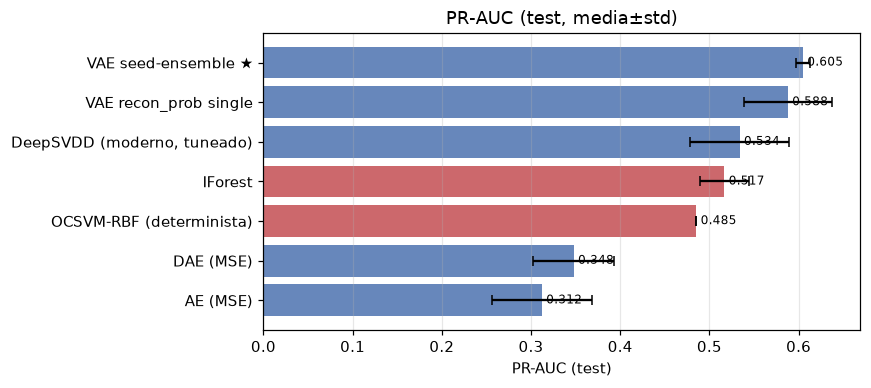

,modelo,pr_auc,pr_auc_std,roc_auc
0,VAE seed-ensemble ★,0.605,0.008,0.749
1,VAE recon_prob single,0.588,0.049,0.741
2,"DeepSVDD (moderno, tuneado)",0.534,0.055,0.766
3,IForest,0.517,0.027,0.671
4,OCSVM-RBF (determinista),0.485,0.000,0.695
5,DAE (MSE),0.348,0.045,0.599
6,AE (MSE),0.312,0.056,0.548


--- maiz ---


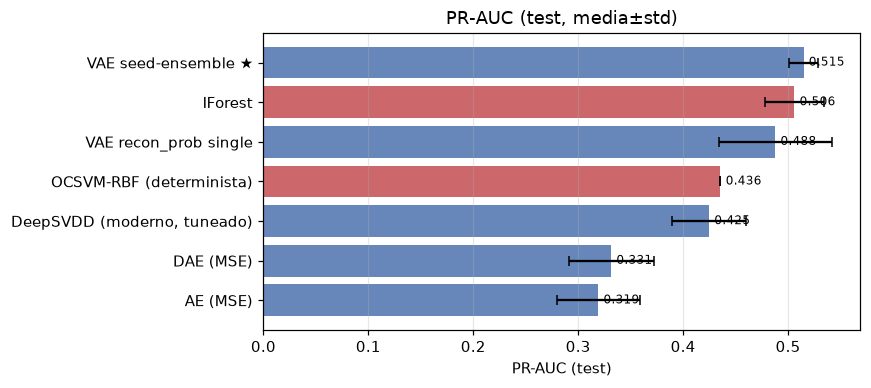

,modelo,pr_auc,pr_auc_std,roc_auc
0,VAE seed-ensemble ★,0.515,0.013,0.655
1,IForest,0.506,0.028,0.649
2,VAE recon_prob single,0.488,0.054,0.630
3,OCSVM-RBF (determinista),0.436,0.000,0.610
4,"DeepSVDD (moderno, tuneado)",0.425,0.035,0.631
5,DAE (MSE),0.331,0.040,0.553
6,AE (MSE),0.319,0.039,0.536


In [5]:
def ens_scores(cultivo, dset, base):
    miembros = [VAEDetector(**BEST[cultivo], score_mode="recon_prob",
                n_mc_samples=50, max_epochs=300, patience=30, random_state=base+i) for i in range(10)]
    return EnsembleDetector(miembros).fit(dset.X_train).score_samples(dset.X_test)

lb = {}
for cultivo, dset in datasets.items():
    lb[cultivo] = lab.leaderboard({
      "VAE seed-ensemble ": [lab.metrics(ens_scores(cultivo, dset, b), dset.y_test) for b in [42,52,62]],
      "VAE recon_prob single": [lab.metrics(VAEDetector(**BEST[cultivo],
            score_mode="recon_prob", n_mc_samples=50, max_epochs=300, patience=30, random_state=s)
            .fit(dset.X_train).score_samples(dset.X_test), dset.y_test) for s in SEEDS],
      "AE (MSE)": [lab.metrics(AEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="mse",
            max_epochs=300, patience=30, random_state=s)
            .fit(dset.X_train).score_samples(dset.X_test), dset.y_test) for s in SEEDS],
      "DAE (MSE)": [lab.metrics(DenoisingAEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="mse",
            max_epochs=300, patience=30, random_state=s)
            .fit(dset.X_train).score_samples(dset.X_test), dset.y_test) for s in SEEDS],
      "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3, random_state=s)
            .fit(dset.X_train).score_samples(dset.X_test), dset.y_test) for s in SEEDS],   # estocástico → std
      "DeepSVDD (moderno, tuneado)": [lab.metrics(DeepODDetector(algo="deepsvdd", epochs=300,
            batch_size=64, random_state=s, **DSVDD_BEST[cultivo])
            .fit(dset.X_train).score_samples(dset.X_test), dset.y_test) for s in SEEDS],
      "OCSVM-RBF (determinista)": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
            .fit(dset.X_train).score_samples(dset.X_test), dset.y_test)],                   # 1 corrida → std 0
    })
    print(f"--- {cultivo} ---")
    lab.plot_leaderboard(lb[cultivo]); plt.show()
    display(lb[cultivo][["modelo","pr_auc","pr_auc_std","roc_auc"]].round(3))

## 6.2 · Recapitulación del recorrido (soja y maíz)
La historia en una tabla. Los **PR-AUC salen del leaderboard vivo de arriba** (`lb`, celda
7.1) — no hay ningún número escrito a mano: si cambiás las semillas o el pipeline, esta tabla
se mueve sola con la corrida.

In [7]:
etapas = [
    ("nb1", "Isolation Forest (baseline)",  "IForest",                       "listón no neuronal, varianza baja"),
    ("nb1", "One-Class SVM (RBF)",          "OCSVM-RBF (determinista)",     "kernel gaussiano ≈ IForest; el lineal fracasa (nb1)"),
    ("nb2", "AE (score MSE)",               "AE (MSE)",                      "el MSE plano no alcanza"),
    ("nb2", "DAE (score MSE)",              "DAE (MSE)",                     "el denoising no cambia el cuello de botella"),
    ("nb3", "VAE recon_prob (single)",      "VAE recon_prob single",         "el SCORE probabilístico es el salto vs MSE"),
    ("nb4", "VAE seed-ensemble ×10 ★",      "VAE seed-ensemble ★",           "MODELO FINAL: baja la varianza y sube la media"),
    ("nb7", "DeepSVDD (moderno, tuneado)",  "DeepSVDD (moderno, tuneado)",   "tuneado (7.0) y a presupuesto parejo, por debajo del VAE"),
]

filas = []
for cultivo in datasets:
    pr = dict(zip(lb[cultivo]["modelo"], lb[cultivo]["pr_auc"]))   # PR-AUC reales, tomados del leaderboard 7.1
    for nb_, etapa, clave, conclusion in etapas:
        filas.append({"cultivo": cultivo, "nb": nb_, "etapa": etapa,
                      "PR-AUC (test)": round(pr[clave], 3), "conclusión": conclusion})
recap = pd.DataFrame(filas)
recap

,cultivo,nb,etapa,PR-AUC (test),conclusión
0,soja,nb1,Isolation Forest (baseline),0.517,"listón no neuronal, varianza baja"
1,soja,nb1,One-Class SVM (RBF),0.485,kernel gaussiano ≈ IForest; el lineal fracasa ...
2,soja,nb2,AE (score MSE),0.312,el MSE plano no alcanza
3,soja,nb2,DAE (score MSE),0.348,el denoising no cambia el cuello de botella
4,soja,nb3,VAE recon_prob (single),0.588,el SCORE probabilístico es el salto vs MSE
5,soja,nb4,VAE seed-ensemble ×10 ★,0.605,MODELO FINAL: baja la varianza y sube la media
6,soja,nb7,"DeepSVDD (moderno, tuneado)",0.534,"tuneado (7.0) y a presupuesto parejo, por deba..."
7,maiz,nb1,Isolation Forest (baseline),0.506,"listón no neuronal, varianza baja"
8,maiz,nb1,One-Class SVM (RBF),0.436,kernel gaussiano ≈ IForest; el lineal fracasa ...
9,maiz,nb2,AE (score MSE),0.319,el MSE plano no alcanza


Tras analizar todo lo visto, concluimos que el mejor modelo para soja es el ensemble de VAEs (seed-ensemble ×10, recon_prob), y para maíz también es el ensemble de VAEs (con su propia arquitectura, latent_dim=24 en vez de 16) — en todas las comparaciones que hicimos, el ensemble superó al VAE single en los dos cultivos, aunque la ventaja es más chica en maíz.

Vimos que es un problema complejo, donde la determinación de si el rinde es anómalo o no no depende únicamente del clima, sino de factores externos (plagas, factores del suelo, manejo, granizo) que no están en nuestro dataset actual. Esto se confirma de varias formas: en el PCA del espacio de features, una parte de las anomalías se separa (firma de sequía) pero la mayoría queda mezclada con lo normal; y en el cross-modelo, familias de detectores completamente distintas (IForest, OCSVM, AE, VAE) fallan sistemáticamente en las mismas muestras, que además comparten un clima casi normal frente a las que sí se detectan. Es un techo de señal, no de modelo.

En el camino probamos varios enfoques: los baselines clásicos (Z-Score, Mahalanobis, Isolation Forest, One-Class SVM), autoencoders con error de reconstrucción (AE y DAE con MSE), que resultaron muy por debajo del resto porque el MSE plano no pondera la confianza del decoder; el VAE con distintos scores (recon_error, neg_elbo, recon_prob), donde el salto grande vino de usar un score probabilístico en vez de MSE; y un método moderno de deep anomaly detection (DeepSVDD, tuneado a presupuesto parejo), que quedó por debajo del VAE. También probamos correr detectores shallow sobre el espacio latente del VAE/AE, sin mejora sobre el score directo.

Chequeamos además la robustez a ruido del modelo final: inyectando ruido gaussiano creciente sobre las features de test (simulando el tipo de error de medición que realmente pueden tener las estaciones climáticas y los satélites), medimos cómo se degrada el PR-AUC del ensemble a medida que sube el nivel de ruido, para ver hasta qué punto el detector es confiable ante datos de entrada imperfectos.

En definitiva, el modelo llega a un techo de PR-AUC de alrededor de 0.6 en soja (algo más bajo en maíz), no porque el modelo esté mal elegido, sino porque buena parte de las anomalías de rinde no tienen una firma climática detectable con los datos que tenemos hoy.